In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pymssql

conn = pymssql.connect(
    server='localhost',
    port=1433,
    user='sa',
    password='',   # the MSSQL_SA_PASSWORD 
    database='AdventureWorksDW2025'
)


#### Sample Query, if from database

In [54]:
query = """
SELECT 
    d.CalendarYear AS [Year],
    pc.EnglishProductCategoryName AS [Category],
    SUM(f.SalesAmount) AS [Total Sales]
FROM 
    FactInternetSales f
JOIN 
    DimDate d ON f.OrderDateKey = d.DateKey
JOIN 
    DimProduct p ON f.ProductKey = p.ProductKey
JOIN 
    DimProductSubcategory ps ON p.ProductSubcategoryKey = ps.ProductSubcategoryKey
JOIN 
    DimProductCategory pc ON ps.ProductCategoryKey = pc.ProductCategoryKey
GROUP BY 
    d.CalendarYear, 
    pc.EnglishProductCategoryName
ORDER BY 
    [Year] ASC, 
    [Total Sales] DESC;
"""



In [55]:
product_category_df = pd.read_sql(query, conn)
product_category_df['Total Sales'] = product_category_df['Total Sales'].astype(float).round(2)
product_category_df.head(25)

C:\Users\adaad\AppData\Local\Temp\ipykernel_17096\384704737.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  product_category_df = pd.read_sql(query, conn)


,Year,Category,Total Sales
0,2010,Bikes,43421.04
1,2011,Bikes,7075525.93
2,2012,Bikes,5839695.33
3,2012,Accessories,2147.08
4,2012,Clothing,642.79
5,2013,Bikes,15359502.36
6,2013,Accessories,668241.53
7,2013,Clothing,323806.45
8,2014,Accessories,30371.35
9,2014,Clothing,15323.37


In [ ]:
total_sales_2013 = product_category_df[product_category_df['Year'] == 2013]['Total Sales'].sum()
print(f"Total sales in 2013: {total_sales_2013:.2f}")

Total sales in 2013: $16351550.34


In [57]:
(668241.53 + 323806.45) / (15359502.36+  668241.53 + 323806.45) * 100

6.066996458269779

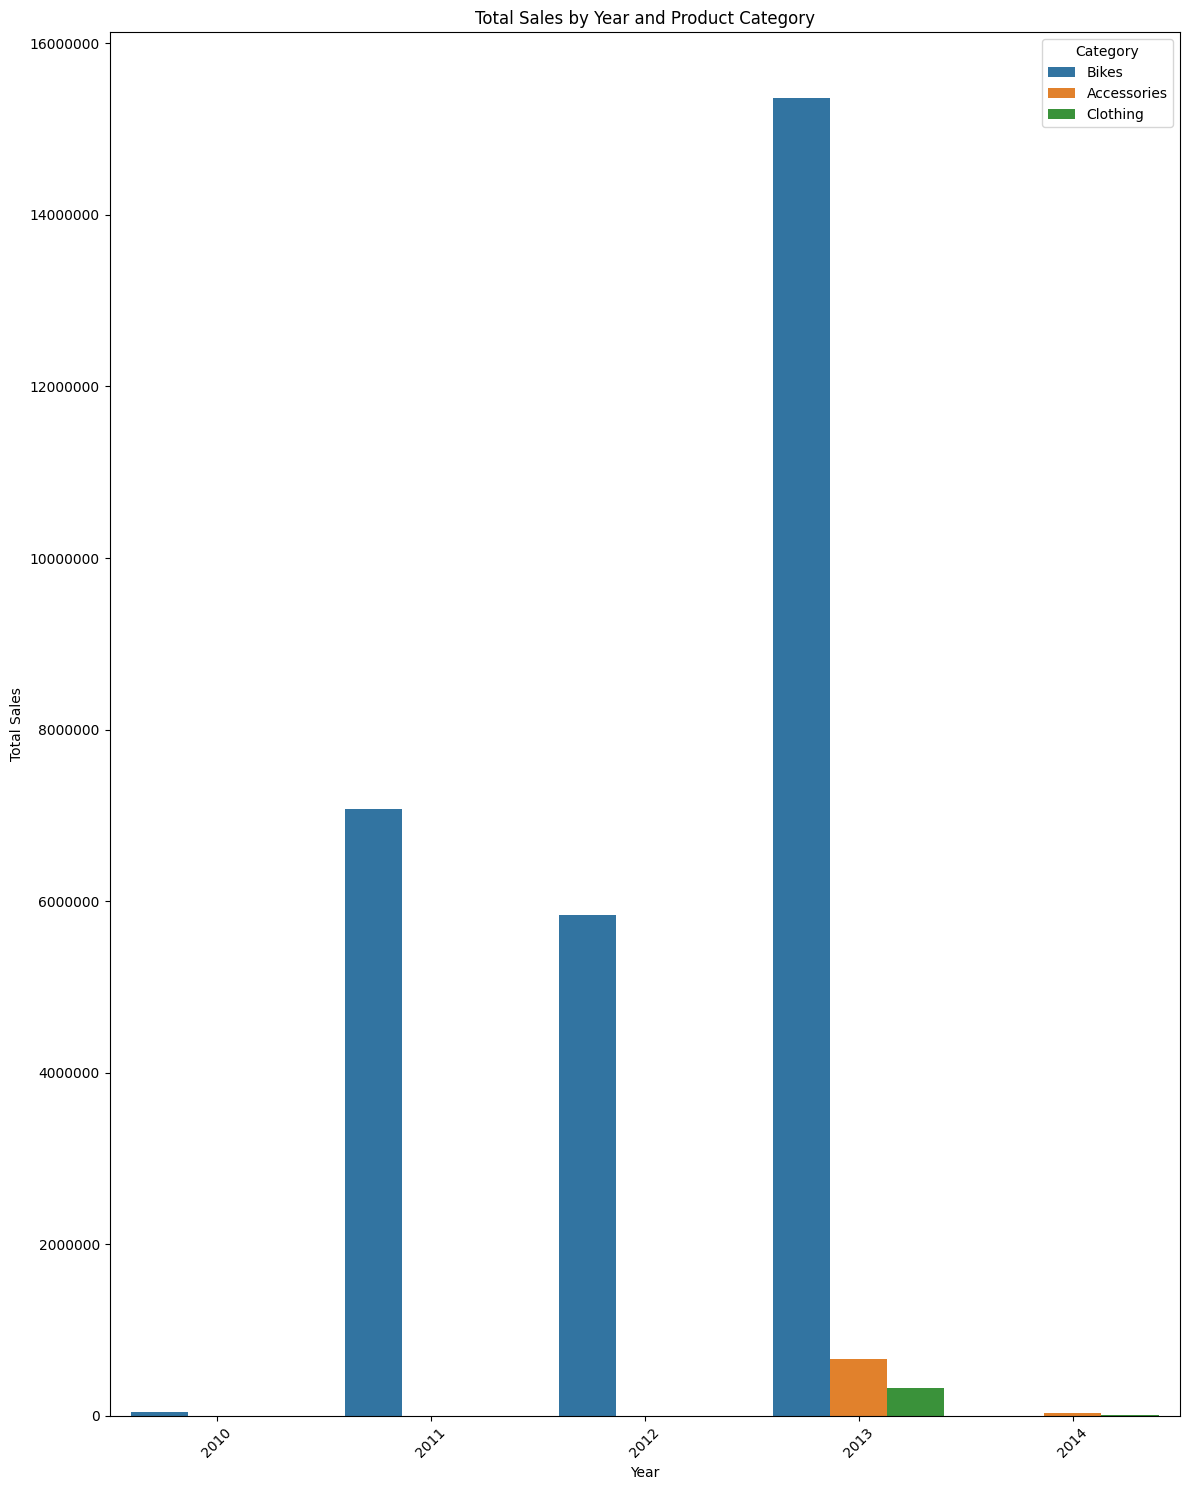

In [51]:
plt.figure(figsize=(12, 15))
sns.barplot(data=product_category_df, x='Year', y='Total Sales', hue='Category')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Total Sales by Year and Product Category')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Total Sales by Year and Product Category were down after 2013 because of the abscence of Bike sales. Prior to 2012, the business only sold bikes and in the years that followed, Bikes were the highest selling category, even after they introduced Accessories and Clothing. Hence, the business should only focus on selling Bikes. Despite the efforts to diversify the product categories, the business heavily relied on Bike sales. It's also possible that there's incomplete data for 2014 since it's very unlikely that Bike sales would be axed after a peak in the previous year. 

**Goal:** Increase Sales while continuing to diversify product categories and reducing dependence on Bike sales. 

**CSF**: Continue selling bikes to maintain sales performance while growing the other categories, Accessories and Clothing to become more relevant sales contributors. 

**KPI**: Category Revenue Mix Percentage  
**Definition:** Share of total sales revenue contributed by non-Bike categories, in this case it's Accessories and Clothing

**Formula:** (Sum of non-Bike category Revenue / Total Revenue) * 100

**Target:** Since more than 95% of the sales for 2013 came from bikes, a target threshold of 10% non-Bike revenue mix for the next year is set. If the revenue mix becomes less than 5%, then it becomes a problem. 

**Owner & Cadence:** Sales Director; reviewed and reported monthly. 


**Solutions and Recommendations**: Use the revenue from Bike sales to invest in diversifying the product categories while the business is dependent on it, with the goal of becoming less dependent on Bike sales alone with a more mature product category stack in the future. Selling of bikes could also be supplemented with relevant Accessories and Clothing for bikers so that people who would buy a bike would also be more likely to buy Accessories and Clothing. Consider also creating package or bundled deals, so that buying from one category would also lead to the purchase of a product from another category. 